<a href="https://colab.research.google.com/github/vichacker1234/Vicstatistics/blob/main/notebooks/01_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso Técnico: Sistema de Análisis Inteligente para Operaciones Rappi**

# **Procesamiento de los datos**
## **Sistema de Análisis Inteligente para Operaciones**

Este notebook realiza el procesamiento y limpieza de datos operacionales para preparar la información utilizada por el sistema de insights automáticos y el bot conversacional.

In [1]:
# Crear estructura del proyecto (solo primera vez)
!mkdir -p data/raw data/processed src

# **1. Cargar las librerías para el procesamiento de datos**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# **2. Cargar los datasets**

In [5]:
## Datafrane de las métricas
df_metricas_input=pd.read_excel('/content/Sistema de Análisis Inteligente para Operaciones Rappi - Dummy Data (2).xlsx',sheet_name='RAW_INPUT_METRICS')
# parte superior de la base de métricas
df_metricas_input.head()



,COUNTRY,CITY,ZONE,ZONE_TYPE,ZONE_PRIORITIZATION,METRIC,L8W_ROLL,L7W_ROLL,L6W_ROLL,L5W_ROLL,L4W_ROLL,L3W_ROLL,L2W_ROLL,L1W_ROLL,L0W_ROLL
0,EC,Quito,San Martin de Porras,Non Wealthy,Not Prioritized,Retail SST > SS CVR,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,BR,Bauru,FS Parque Jardim Europa/Vila Riachuelo - BAU,Non Wealthy,Not Prioritized,Restaurants SST > SS CVR,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,MX,Mexicali,MXL_Universidad,Wealthy,Prioritized,Retail SST > SS CVR,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,CL,Santiago De Chile,Colina,Non Wealthy,Not Prioritized,Retail SST > SS CVR,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,MX,Guadalajara,Valle Real,Wealthy,High Priority,Gross Profit UE,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


In [6]:
# dataset de las órdenes
df_raw_orders=pd.read_excel('/content/Sistema de Análisis Inteligente para Operaciones Rappi - Dummy Data (2).xlsx',sheet_name='RAW_ORDERS')
# Parte superior de las órdenes
df_raw_orders.head()

,COUNTRY,CITY,ZONE,METRIC,L8W,L7W,L6W,L5W,L4W,L3W,L2W,L1W,L0W
0,CO,Bogota,Chapinero,Orders,264650.0,261767.0,277005.0,279886.0,277954.0,275344.0,275633.0,279048.0,274376.0
1,CO,Bogota,Usaquén,Orders,233674.0,224436.0,241602.0,240411.0,240786.0,236591.0,241475.0,238649.0,236876.0
2,PE,Lima,Miraflores,Orders,123252.0,125820.0,126245.0,123770.0,126467.0,124376.0,124751.0,123431.0,124757.0
3,CO,Medellin,Poblado_guayabal,Orders,123163.0,118244.0,124015.0,108165.0,106785.0,117266.0,120384.0,121428.0,117824.0
4,PE,Lima,San isidro,Orders,109987.0,114369.0,114077.0,113302.0,115501.0,113639.0,113772.0,112622.0,114141.0


In [7]:
print("Las dimensiones de la base de métricas es:", df_metricas_input.shape)
print("Las dimensiones de la base de órdenes es:", df_raw_orders.shape)

Las dimensiones de la base de métricas es: (12573, 15)
Las dimensiones de la base de órdenes es: (1242, 13)


# **3. Análisis descriptivo y exploratiorio de las bases**

In [8]:
## información general de la naturaleza de los campos de la base relacionada con las métricas
df_metricas_input.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12573 entries, 0 to 12572
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   COUNTRY              12573 non-null  object 
 1   CITY                 12573 non-null  object 
 2   ZONE                 12573 non-null  object 
 3   ZONE_TYPE            12573 non-null  object 
 4   ZONE_PRIORITIZATION  12573 non-null  object 
 5   METRIC               12573 non-null  object 
 6   L8W_ROLL             12460 non-null  float64
 7   L7W_ROLL             12466 non-null  float64
 8   L6W_ROLL             12462 non-null  float64
 9   L5W_ROLL             12467 non-null  float64
 10  L4W_ROLL             12475 non-null  float64
 11  L3W_ROLL             12501 non-null  float64
 12  L2W_ROLL             12518 non-null  float64
 13  L1W_ROLL             12530 non-null  float64
 14  L0W_ROLL             12573 non-null  float64
dtypes: float64(9), object(6)
memory usag

Se detectaron errores de tipado en las variables cualitativas detalladas a continuación. Es necesario realizar la conversión de ?'string' a 'category' para reflejar correctamente su naturaleza:

* COUNTRY          
* CITY          
* ZONE               
* ZONE_TYPE           
* ZONE_PRIORITIZATION   
* METRIC                


In [9]:
## información general de la naturaleza de los campos de la base relacionada con las órdenes
df_raw_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   COUNTRY  1242 non-null   object 
 1   CITY     1242 non-null   object 
 2   ZONE     1242 non-null   object 
 3   METRIC   1242 non-null   object 
 4   L8W      1021 non-null   float64
 5   L7W      1022 non-null   float64
 6   L6W      1021 non-null   float64
 7   L5W      1016 non-null   float64
 8   L4W      1003 non-null   float64
 9   L3W      999 non-null    float64
 10  L2W      1000 non-null   float64
 11  L1W      994 non-null    float64
 12  L0W      998 non-null    float64
dtypes: float64(9), object(4)
memory usage: 126.3+ KB


Por otro lado, con respecto a la base relacionada con las órdenes, se evidencia que las siguientes variables presentan problemas de tipado:

*  COUNTRY
*  CITY
*  ZONE
*  METRIC

Es decir, son variables que debido a su naturaleza deberían ser categóricas

# **4. Análisis de valores faltantes**

In [10]:
## Valores faltantes para las variables del dataframe de las métricas
df_metricas_input.isna().sum().sort_values(ascending=False)

,0
L8W_ROLL,113
L6W_ROLL,111
L7W_ROLL,107
L5W_ROLL,106
L4W_ROLL,98
L3W_ROLL,72
L2W_ROLL,55
L1W_ROLL,43
ZONE_PRIORITIZATION,0
METRIC,0


A partir de la tabla resumen, se puede evidenciar que  para la base de métricas, la variables con más valores faltantes es la variable **L8W_ROLL** con un total de $113$ valores nulos.

In [11]:
## Valores faltantes para las variables del dataframe de los órdenes
df_raw_orders.isna().sum().sort_values(ascending=False)

,0
L1W,248
L0W,244
L3W,243
L2W,242
L4W,239
L5W,226
L8W,221
L6W,221
L7W,220
METRIC,0


A partir de la tabla resumen, se puede evidenciar que  para la base de órdenes, la variables con más valores faltantes es la variable **L1W** con un total de $248$ valores nulos.

#  **5. Análisis de valores duplicados**

In [12]:
## Analizar el valore de los duplicados de cada una de las base
print("Duplicados de la metricas:", df_metricas_input.duplicated().sum())
print("Duplicados orders:", df_raw_orders.duplicated().sum())

Duplicados de la metricas: 963
Duplicados orders: 0


El análisis de duplicados en la base de métricas reveló la existencia de $963$ registros redundantes. Esta duplicidad puede introducir sesgos significativos en el cálculo, la medición y la construcción de indicadores, afectando tanto los resultados generales como los análisis agregados. Por otro laddo, la base relacionada con los órdenes no evidencia duplicidad en los valores.

# **6. Estadísticas descriptivas**

In [13]:
#Estadísticas descriptivas de la base de métricas
df_metricas_input.describe()

,L8W_ROLL,L7W_ROLL,L6W_ROLL,L5W_ROLL,L4W_ROLL,L3W_ROLL,L2W_ROLL,L1W_ROLL,L0W_ROLL
count,12460.000000,12466.000000,12462.000000,12467.000000,12475.000000,12501.000000,12518.000000,12530.000000,12573.000000
mean,0.503826,0.485613,0.491289,0.522463,0.444753,0.414644,0.437222,0.451602,0.481998
std,4.101102,4.026571,3.935082,3.976455,4.928371,5.715251,5.249517,5.449286,5.009178
min,-93.510439,-109.343740,-71.673324,-82.328231,-156.058339,-229.193676,-114.012822,-109.355505,-97.133832
25%,0.158966,0.154906,0.156691,0.161290,0.161646,0.162224,0.165981,0.168937,0.159952
50%,0.506096,0.491137,0.484049,0.486222,0.489128,0.489958,0.494337,0.512072,0.500897
75%,0.865126,0.863287,0.865072,0.868522,0.869204,0.872499,0.874429,0.880628,0.875664
max,320.500000,323.700000,326.900000,336.300000,347.000000,361.500000,371.800000,383.800000,393.900000


In [14]:
# Estadísticas descriptivas de la base de órdenes
df_raw_orders.describe()

,L8W,L7W,L6W,L5W,L4W,L3W,L2W,L1W,L0W
count,1021.000000,1022.000000,1021.000000,1016.000000,1003.000000,999.000000,1000.000000,994.000000,998.000000
mean,5028.824682,5044.317025,5148.448580,5124.618110,5196.881356,5211.296296,5277.077000,5187.360161,5233.680361
std,16322.834038,16217.664529,16879.266244,16730.219084,16826.065061,16808.298563,17008.844912,16935.264838,16854.034768
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,88.000000,90.000000,86.000000,92.750000,106.000000,100.000000,101.750000,109.250000,102.000000
50%,875.000000,861.500000,876.000000,853.500000,903.000000,906.000000,896.500000,889.000000,906.000000
75%,3400.000000,3385.000000,3431.000000,3450.000000,3473.500000,3537.500000,3562.000000,3459.250000,3525.500000
max,264650.000000,261767.000000,277005.000000,279886.000000,277954.000000,275344.000000,275633.000000,279048.000000,274376.000000


# **7. Visualización**



In [15]:
df_metricas_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12573 entries, 0 to 12572
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   COUNTRY              12573 non-null  object 
 1   CITY                 12573 non-null  object 
 2   ZONE                 12573 non-null  object 
 3   ZONE_TYPE            12573 non-null  object 
 4   ZONE_PRIORITIZATION  12573 non-null  object 
 5   METRIC               12573 non-null  object 
 6   L8W_ROLL             12460 non-null  float64
 7   L7W_ROLL             12466 non-null  float64
 8   L6W_ROLL             12462 non-null  float64
 9   L5W_ROLL             12467 non-null  float64
 10  L4W_ROLL             12475 non-null  float64
 11  L3W_ROLL             12501 non-null  float64
 12  L2W_ROLL             12518 non-null  float64
 13  L1W_ROLL             12530 non-null  float64
 14  L0W_ROLL             12573 non-null  float64
dtypes: float64(9), object(6)
memory usag

In [16]:
# filtarr la base por las variables cuantitativas
df_float_metrica = df_metricas_input.select_dtypes(include=['float'])
df_float_metrica.head()

,L8W_ROLL,L7W_ROLL,L6W_ROLL,L5W_ROLL,L4W_ROLL,L3W_ROLL,L2W_ROLL,L1W_ROLL,L0W_ROLL
0,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


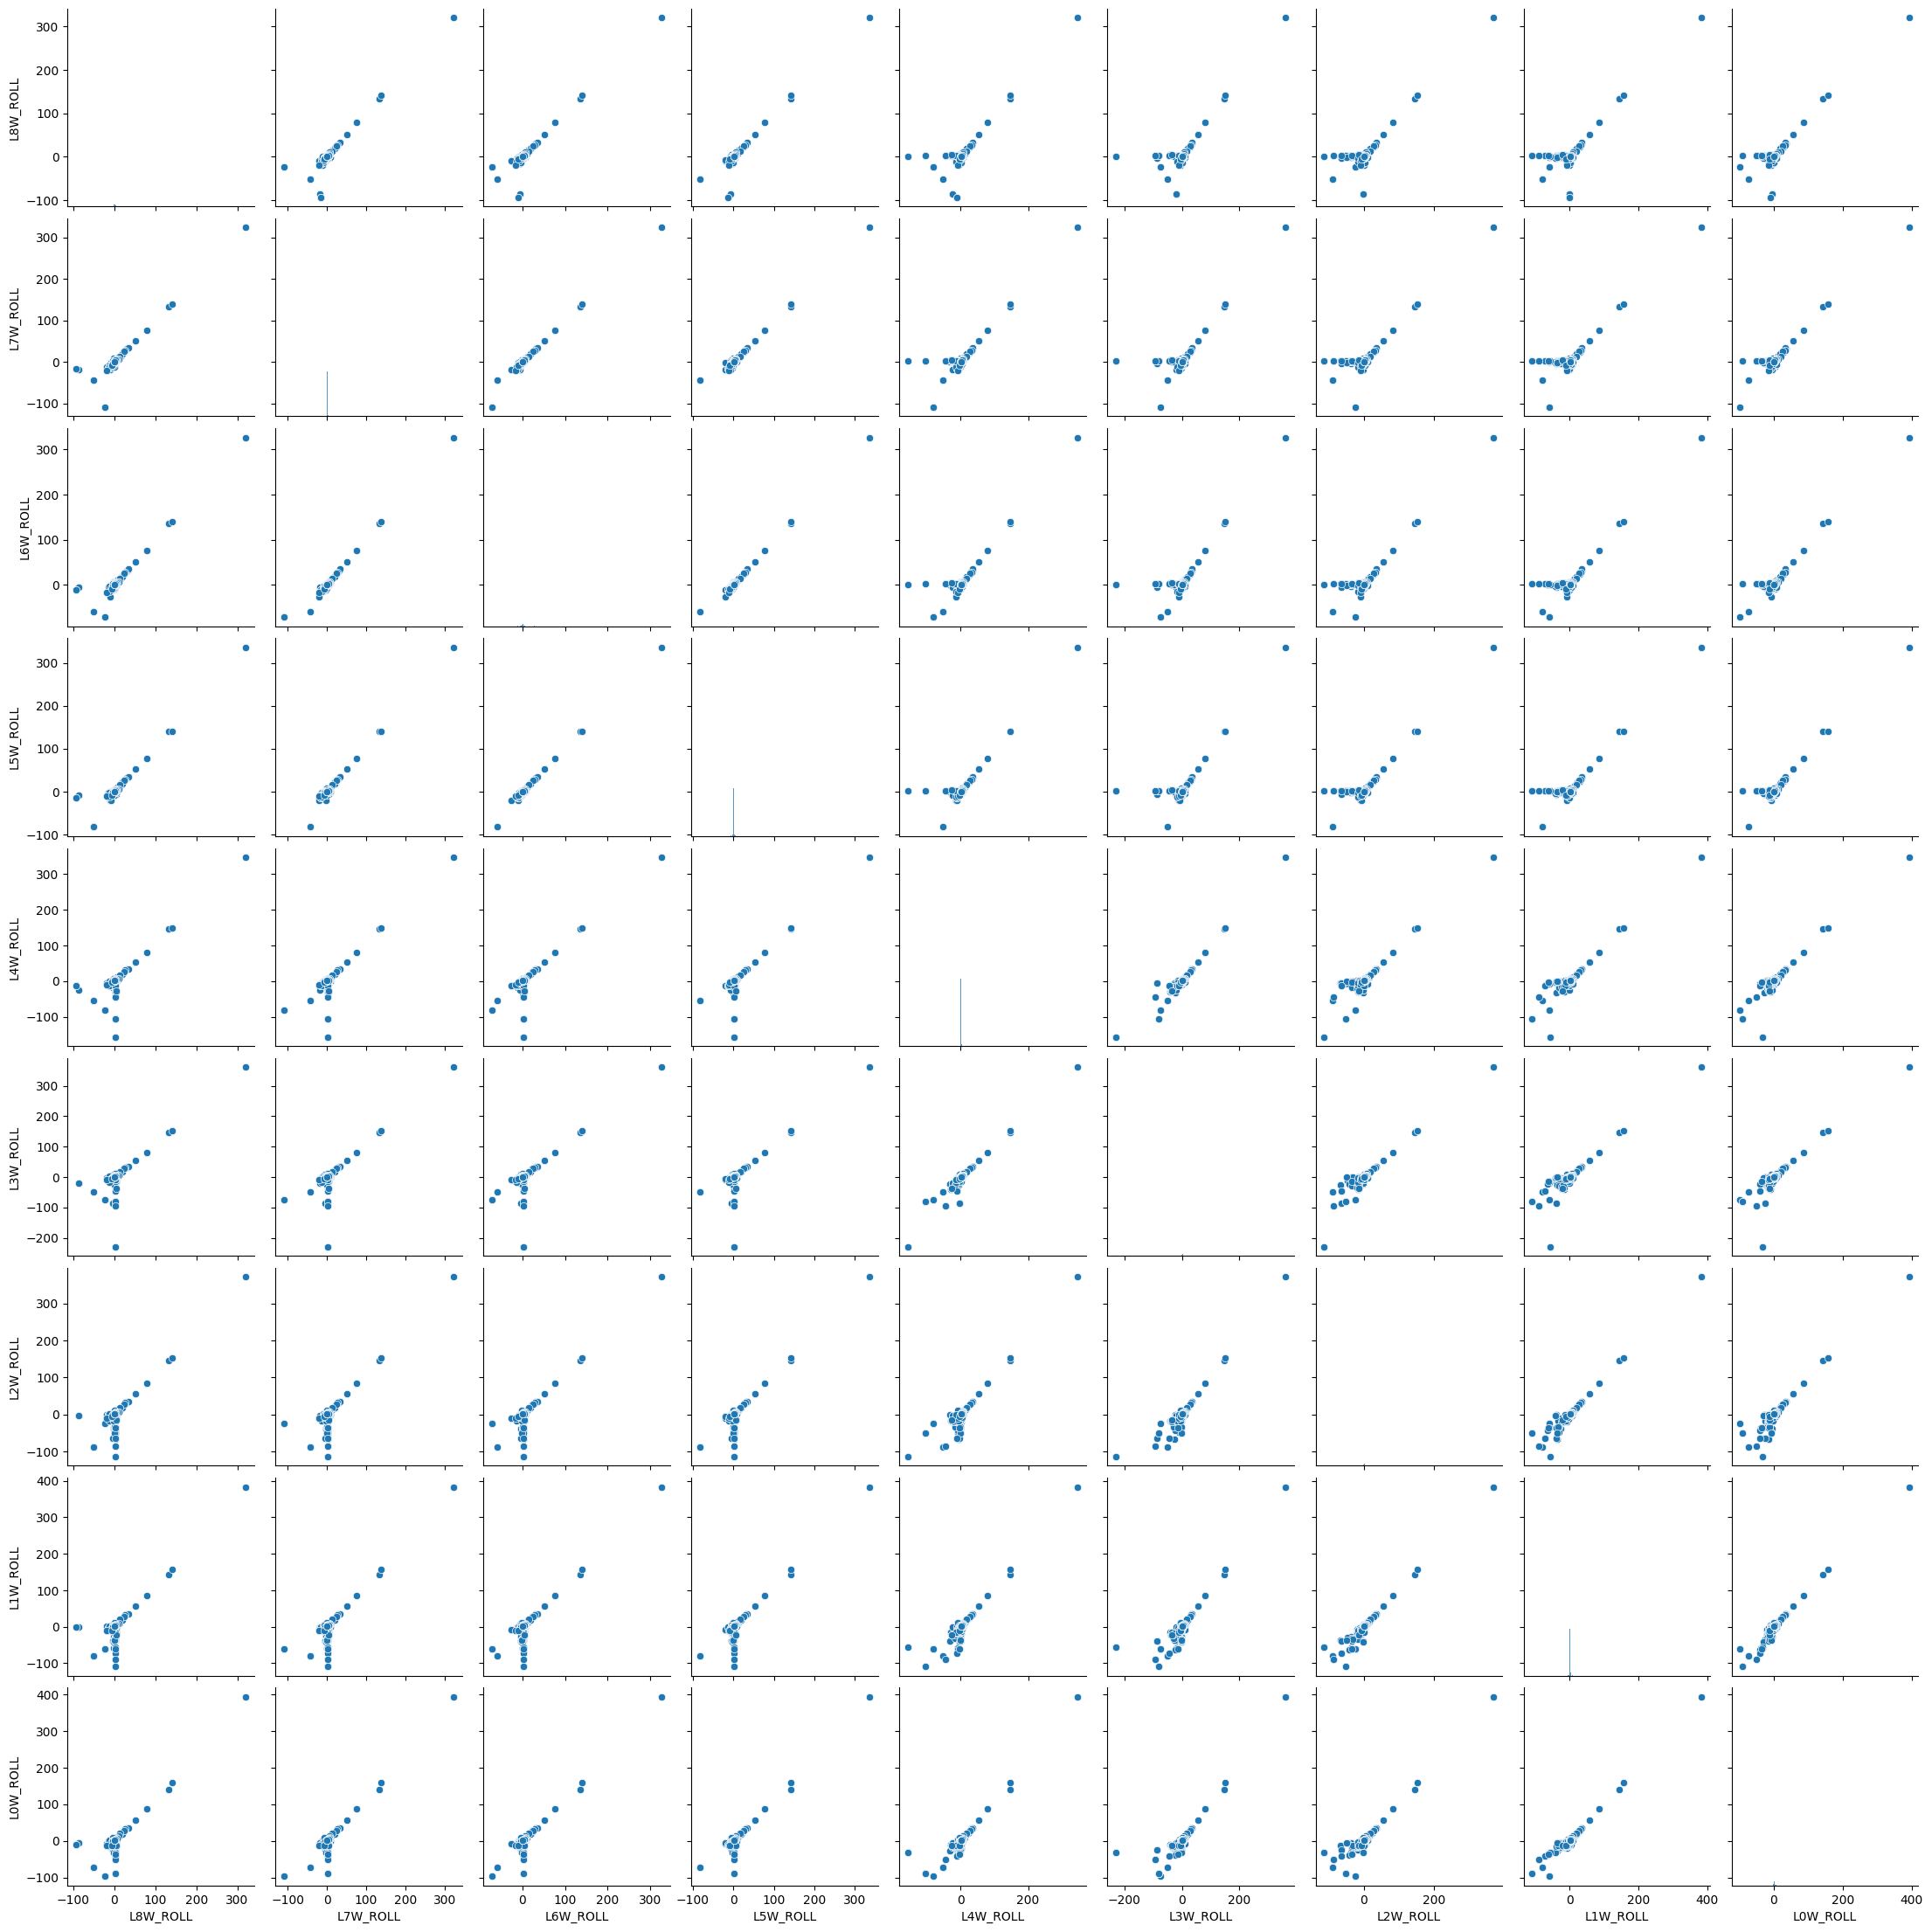

In [17]:
sns.pairplot(df_float_metrica)
plt.show()

A partir del análisis descriptivo y exploratorio, se observa una alta correlación entre los valores de las métricas a lo largo de las ocho semanas analizadas. En términos generales, las métricas semanales presentan una relación directa y positiva entre distintos periodos, lo que sugiere un comportamiento consistente en el tiempo.

## **Limpieza básica**

In [26]:
## Construir una fucnión de limpieza básica
def clean_columns(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )
    return df


In [27]:
metrics_df = clean_columns(df_float_metrica)
orders_df = clean_columns(df_float_metrica)

In [29]:
metrics_df.head()

,l8w_roll,l7w_roll,l6w_roll,l5w_roll,l4w_roll,l3w_roll,l2w_roll,l1w_roll,l0w_roll
0,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


In [28]:
orders_df.head()

,l8w_roll,l7w_roll,l6w_roll,l5w_roll,l4w_roll,l3w_roll,l2w_roll,l1w_roll,l0w_roll
0,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


## **Manejo de valores nulos**

In [25]:
def handle_missing(df):

    num_cols = df.select_dtypes(include="number").columns
    cat_cols = df.select_dtypes(include="object").columns

    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df[cat_cols] = df[cat_cols].fillna("unknown")

    return df


In [24]:
## Implementación de la función para imputar valores nulos a través de la mediana
metrics_df = handle_missing(metrics_df)
orders_df = handle_missing(orders_df)

In [30]:
metrics_df.head()

,l8w_roll,l7w_roll,l6w_roll,l5w_roll,l4w_roll,l3w_roll,l2w_roll,l1w_roll,l0w_roll
0,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534


In [31]:
orders_df.head()

,l8w_roll,l7w_roll,l6w_roll,l5w_roll,l4w_roll,l3w_roll,l2w_roll,l1w_roll,l0w_roll
0,0.602339,0.538596,0.657760,0.709402,0.781532,0.731758,0.676429,0.670137,0.735549
1,0.857544,0.926667,0.880000,0.525000,0.450000,0.425000,0.250000,0.450000,0.475000
2,0.900823,0.904237,0.905766,0.900928,0.895019,0.888999,0.894802,0.897732,0.897864
3,0.798946,0.770919,0.772061,0.784609,0.799962,0.804492,0.737508,0.733916,0.741457
4,3.914477,3.827934,3.534116,3.486583,3.632156,3.473549,3.541963,3.808373,3.780534
